In [1]:
import numpy as np
from src.monte_carlo import monte_carlo_call_price
S_0=100       # current stock price
r=0.05       # risk-free interest rate
sigma=0.20   # volatility
T=1          # time to maturity (years)
K=100        # strike price

9.028797565847178
10.234243089447352
10.329829980672528
10.495395731489152
10.450671090736469


In [2]:
n_runs=100
results = []
for N in [100,1000,10000,100000]:
    prices = []
    for i in range(n_runs):
        prices.append(monte_carlo_call_price(S_0,r,sigma,T,K,N))
    print(N,np.mean(prices),np.std(prices))
    results.append({
        "N": N,
        "mean_price": np.mean(prices),
        "std_price": np.std(prices)
    })

#generates mean and standard deviation of stock prices for different number of simulations

100 10.611205367178183 1.3121178375358558
1000 10.442278092597839 0.4257487439271359
10000 10.455905684017727 0.15886670362531014
100000 10.44704266129492 0.05190545666298158


In [3]:
import pandas as pd
df = pd.DataFrame(results)
df

#table of results above

,N,mean_price,std_price
0,100,10.611205,1.312118
1,1000,10.442278,0.425749
2,10000,10.455906,0.158867
3,100000,10.447043,0.051905


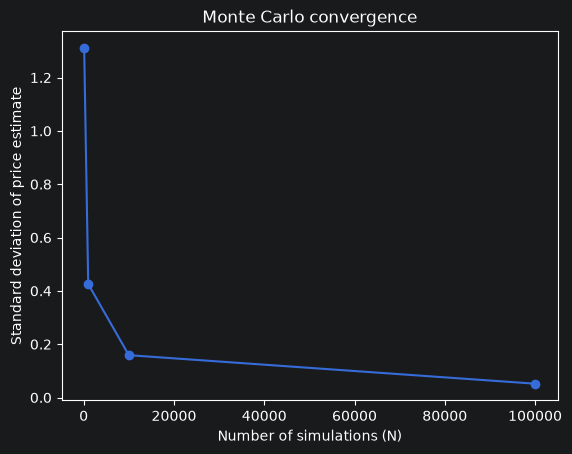

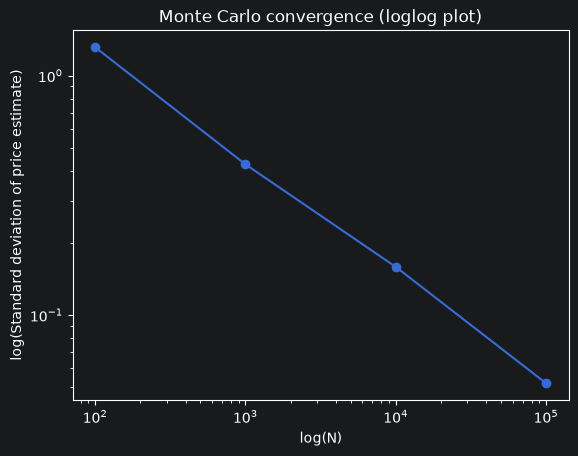

In [4]:
import matplotlib.pyplot as plt
plt.plot(df["N"], df["std_price"], marker="o")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation of price estimate")
plt.title("Monte Carlo convergence")
plt.show()
plt.loglog(df["N"], df["std_price"], marker="o")
plt.xlabel("log(N)")
plt.ylabel("log(Standard deviation of price estimate)")
plt.title("Monte Carlo convergence (loglog plot)")
plt.show()

#normal and log log plots of results above

In [5]:
x = np.log(df["N"])
y = np.log(df["std_price"])

slope, intercept = np.polyfit(x, y, 1)
print("Estimated convergence rate:", slope)

#gradient of log log plot is the estimated convergence rate; should be -0.5

Estimated convergence rate: -0.46363999606974704


In [6]:
from src.black_scholes import call_price

bs_price = float(call_price(S_0,r,sigma,T,K))
print("Black-Scholes price:", bs_price)

#analytical Black-Scholes call price

10.450583572185565
0.6368306511756191
Black-Scholes price: 10.450583572185565


In [7]:
df["error"] = abs(df["mean_price"] - bs_price)
df["percentage_error"] = df["error"] / bs_price * 100
df

#columns added to table showing error between monte-carlo methods and theoretical

,N,mean_price,std_price,error,percentage_error
0,100,10.611205,1.312118,0.160622,1.536965
1,1000,10.442278,0.425749,0.008305,0.079474
2,10000,10.455906,0.158867,0.005322,0.050926
3,100000,10.447043,0.051905,0.003541,0.033882


In [8]:
results_ci = []
for N in [100,1000,10000,100000]:
    Z=np.random.normal(0,1,N)
    ST=S_0*np.exp((r-(sigma**2)/2)*T+sigma*np.sqrt(T)*Z)
    payoff=np.maximum(0,ST-K)
    payoff_mean=np.mean(payoff)
    payoff_std=np.std(payoff,ddof=1)
    prices=payoff_mean*np.exp(-r*T)
    standard_error = np.exp(-r * T) * payoff_std / np.sqrt(N)
    lower = prices - 1.96 * standard_error
    upper = prices + 1.96 * standard_error
    print(N,prices,standard_error,lower,upper)
    results_ci.append({
        "N": N,
        "monte_carlo_price": prices,
        "standard_error": standard_error,
        "lower_confidence_interval": lower,
        "upper_confidence_interval": upper
    })

#as number of simulations increase, standard deviation is smaller and the bounds close in towards the theoretical value

100 10.804018943514823 1.410121691307975 8.040180428551192 13.567857458478453
1000 10.190559975878985 0.47253294692391157 9.264395399908118 11.116724551849853
10000 10.418244371625656 0.1487993721422463 10.126597602226854 10.709891141024459
100000 10.386162280281752 0.04649809558004506 10.295026012944863 10.477298547618641


In [9]:
df_ci = pd.DataFrame(results_ci)
df_ci

#table of results above

,N,monte_carlo_price,standard_error,lower_confidence_interval,upper_confidence_interval
0,100,10.804019,1.410122,8.040180,13.567857
1,1000,10.190560,0.472533,9.264395,11.116725
2,10000,10.418244,0.148799,10.126598,10.709891
3,100000,10.386162,0.046498,10.295026,10.477299


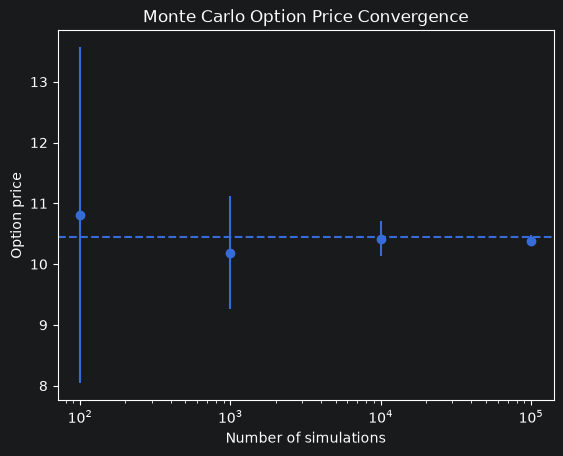

In [10]:
plt.errorbar(
    df_ci["N"],
    df_ci["monte_carlo_price"],
    yerr=1.96 * df_ci["standard_error"],
    fmt="o"
)

plt.axhline(bs_price, linestyle="--")

plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.title("Monte Carlo Option Price Convergence")
plt.show()

#plot of results above, with error bars

In [11]:
from src.antithetic import antithetic_call_price

price = antithetic_call_price(S_0,r,sigma,T,K,10000)
print(price)

#antithetic price

10.305439798370571


In [12]:
n_runs = 100
N = 10000

standard_prices = []
antithetic_prices = []
for i in range(n_runs):
    # Standard Monte Carlo
    standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

    # Antithetic Monte Carlo
    antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))

print("Standard MC:")
print("Mean:", np.mean(standard_prices))
print("Std:", np.std(standard_prices))
print()
print("Antithetic MC:")
print("Mean:", np.mean(antithetic_prices))
print("Std:", np.std(antithetic_prices))

#mean and standard deviations of standard and antithetic prices; the standard deviation for standard is larger than antithetic

Standard MC:
Mean: 10.447353313020667
Std: 0.13754471649471556

Antithetic MC:
Mean: 10.44802099954919
Std: 0.07858780274498449


In [13]:
simulation_sizes = [100, 1000, 10000, 100000]
n_runs = 100
comparison_results = []

for N in simulation_sizes:
    standard_prices = []
    antithetic_prices = []
    for i in range(n_runs):
        # Standard Monte Carlo
        standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

        # Antithetic Monte Carlo
        antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))
    comparison_results.append({
        "N": N,
        "standard_mean": np.mean(standard_prices),
        "standard_std": np.std(standard_prices),
        "antithetic_mean": np.mean(antithetic_prices),
        "antithetic_std": np.std(antithetic_prices)
    })

#varying number of simulations to acquire mean and std of standard and antithetic

In [14]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df

#table of results above

,N,standard_mean,standard_std,antithetic_mean,antithetic_std
0,100,10.333756,1.340259,10.466439,0.681174
1,1000,10.400706,0.489931,10.437304,0.234055
2,10000,10.441248,0.139445,10.457000,0.071219
3,100000,10.451193,0.048103,10.446891,0.022325


In [15]:
comparison_df["variance_reduction"] = (1 -(comparison_df["antithetic_std"] ** 2)
    / (comparison_df["standard_std"] ** 2)) * 100

comparison_df

#added percentage reduction of variance to table

,N,standard_mean,standard_std,antithetic_mean,antithetic_std,variance_reduction
0,100,10.333756,1.340259,10.466439,0.681174,74.169131
1,1000,10.400706,0.489931,10.437304,0.234055,77.177407
2,10000,10.441248,0.139445,10.457000,0.071219,73.915062
3,100000,10.451193,0.048103,10.446891,0.022325,78.459912


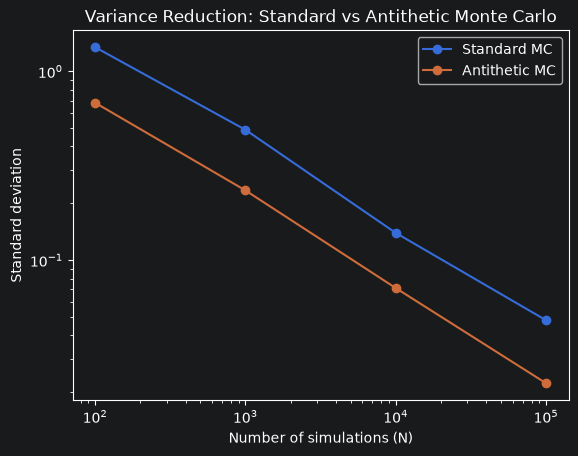

In [16]:
plt.loglog(
    comparison_df["N"],
    comparison_df["standard_std"],
    marker="o",
    label="Standard MC"
)

plt.loglog(
    comparison_df["N"],
    comparison_df["antithetic_std"],
    marker="o",
    label="Antithetic MC"
)

plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation")
plt.title("Variance Reduction: Standard vs Antithetic Monte Carlo")
plt.legend()
plt.show()

#log log plots of both standard and antithetic std

In [17]:
standard_se = comparison_df.loc[
    comparison_df["N"] == 100000, "standard_std"
].iloc[0]

antithetic_se = comparison_df.loc[
    comparison_df["N"] == 100000, "antithetic_std"
].iloc[0]

efficiency = (standard_se / antithetic_se) ** 2

print("Efficiency improvement:", efficiency)
print("Equivalent standard MC simulations:", 100000 * efficiency)

#efficiency calculation: how many more times of simulations standard need to keep up with antithetic

Efficiency improvement: 4.642506615825181
Equivalent standard MC simulations: 464250.66158251814


In [18]:
from src.black_scholes import call_delta

bs_delta = call_delta(S_0,r, sigma, T,K)
print("Black-Scholes Delta:", bs_delta)

#theoretical Black-scholes delta

Black-Scholes Delta: 0.6368306511756191


In [19]:
h=1
N=100000
high_price=monte_carlo_call_price(S_0+h,r,sigma,T,K,N)
low_price=monte_carlo_call_price(S_0-h,r,sigma,T,K,N)
monte_carlo_delta=(high_price-low_price)/(2*h)

print("MC Delta:", monte_carlo_delta)
print("Black-Scholes Delta:", bs_delta)

#monte-carlo delta, but random errors are unrelated in high_price and low_price, so the errors are amplified

MC Delta: 0.6130490414407799
Black-Scholes Delta: 0.6368306511756191


In [21]:
from src.monte_carlo import monte_carlo_call_price_crn
h=1
N=100000
Z=np.random.normal(0,1,N)
high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
monte_carlo_delta=(high_price-low_price)/(2*h)

print("MC Delta:", monte_carlo_delta)
print("Black-Scholes Delta:", bs_delta)

#using common random numbers, results are much closer to theoretical

MC Delta: 0.6374002862616264
Black-Scholes Delta: 0.6368306511756191


In [23]:
h=1
N=100000
n_runs=100

independent_deltas=[]
crn_deltas=[]

for i in range(n_runs):
    #Independent
    high_price=monte_carlo_call_price(S_0+h,r,sigma,T,K,N)
    low_price=monte_carlo_call_price(S_0-h,r,sigma,T,K,N)
    independent_delta=(high_price-low_price)/(2*h)
    independent_deltas.append(independent_delta)

    #CRN
    Z=np.random.normal(0,1,N)
    high_price=monte_carlo_call_price_crn(S_0+h,r,sigma,T,K,N,Z)
    low_price=monte_carlo_call_price_crn(S_0-h,r,sigma,T,K,N,Z)
    crn_delta=(high_price-low_price)/(2*h)
    crn_deltas.append(crn_delta)

print("Independent random numbers")
print("Mean:", np.mean(independent_deltas))
print("Std:", np.std(independent_deltas))

print()

print("Common random numbers")
print("Mean:", np.mean(crn_deltas))
print("Std:", np.std(crn_deltas))

print()

print("Black-Scholes Delta:", bs_delta)

Independent random numbers
Mean: 0.6341042189382509
Std: 0.031932364163225466

Common random numbers
Mean: 0.6365947799905227
Std: 0.0017796481224312743

Black-Scholes Delta: 0.6368306511756191
